## Chapter 3 of *lme4: Mixed-effects modeling with R* (2022)

In [1]:
from hea import data
from hea.R import anova
from hea.models import lme

### 3.1

In [2]:
sleepstudy = data("sleepstudy")
sleepstudy.glimpse()

Rows: 180
Columns: 3
$ Reaction  <f64> 249.56, 258.7047, 250.8006, 321.4398, 356.8519, 414.6901, 382.2038, 290.1486, 430.5853, 466.3535
$ Days      <i64> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
$ Subject  <enum> 308, 308, 308, 308, 308, 308, 308, 308, 308, 308



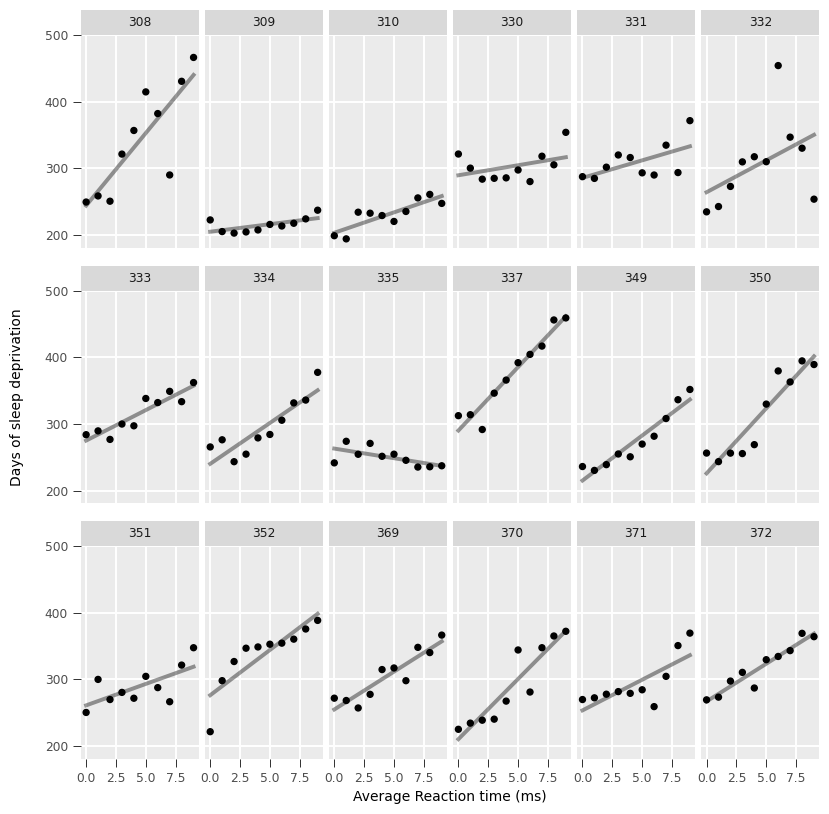

In [3]:
(
    sleepstudy
        .ggplot(x="Days", y="Reaction", group="Subject")
        .geom_point()
        .geom_smooth(method="lm", se=False, color="black")
        .facet_wrap("~Subject", ncol=6)
        .labs(x="Average Reaction time (ms)", y="Days of sleep deprivation")
).show(figsize=(8,8))

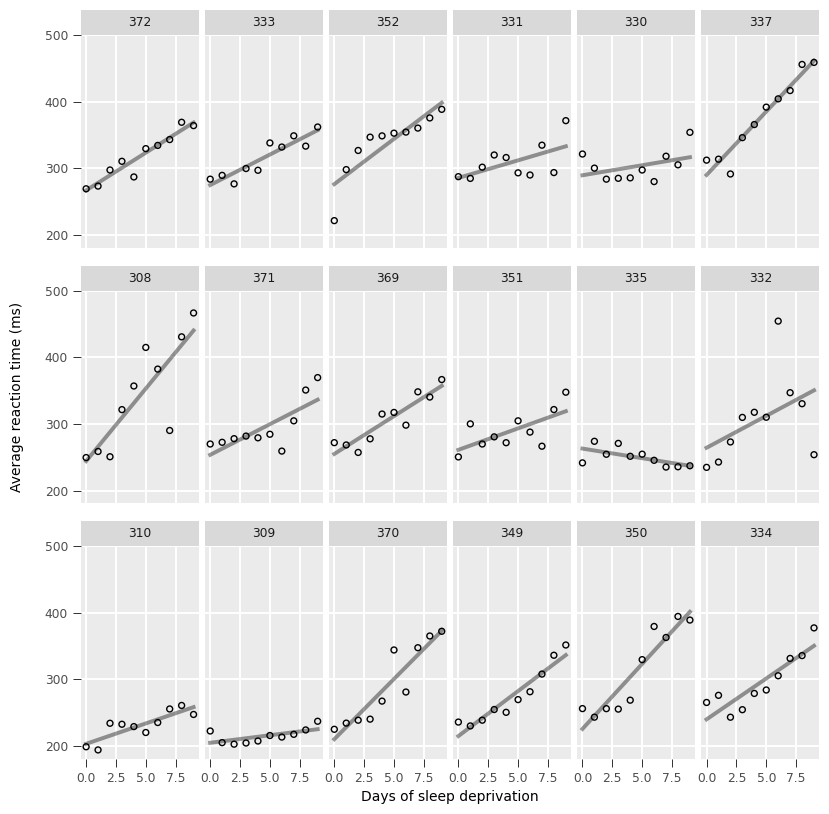

In [4]:
# reorder the panels like Figure 3.1 in Bates
from hea.tidy import col, fct_reorder
sleepstudy = data("sleepstudy").mutate(
    intercept = (
        col("Reaction").mean()
        - ((col("Reaction") * col("Days")).mean() - col("Reaction").mean() * col("Days").mean())
          / ((col("Days") ** 2).mean() - col("Days").mean() ** 2)
          * col("Days").mean()
    ).over("Subject"),
).mutate(Subject=fct_reorder("Subject", "intercept"))

(
    sleepstudy
        .ggplot(x="Days", y="Reaction", group="Subject")
        .geom_point(shape=1)
        .geom_smooth(method="lm", se=False, color="black")
        .facet_wrap("~Subject", ncol=6, as_table=False)
        .labs(x="Days of sleep deprivation", y="Average reaction time (ms)")
).show(figsize=(8, 8))

### 3.2

In [5]:
fm06 = lme("Reaction ~ 1 + Days + (1 + Days|Subject)", sleepstudy, REML=False)
fm06.summary()

Linear mixed model fit by maximum likelihood
Formula: Reaction ~ 1 + Days + (1 + Days|Subject)

      AIC       BIC    logLik -2*log(L) df.resid
1763.9393 1783.0971 -875.9697 1751.9393      174

Scaled residuals:
    Min      1Q Median     3Q    Max
-3.9416 -0.4656 0.0289 0.4636 5.1793

Random effects:
 Groups   Name        Variance Std.Dev. Corr
 Subject  (Intercept) 565.51   23.780
          Days        32.68    5.717    0.08
 Residual             654.94   25.592
Number of obs: 180, groups:  Subject, 18

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   251.405       6.632   37.907
Days           10.467       1.502    6.968

Correlation of Fixed Effects:
     (Intr)
Days -0.138


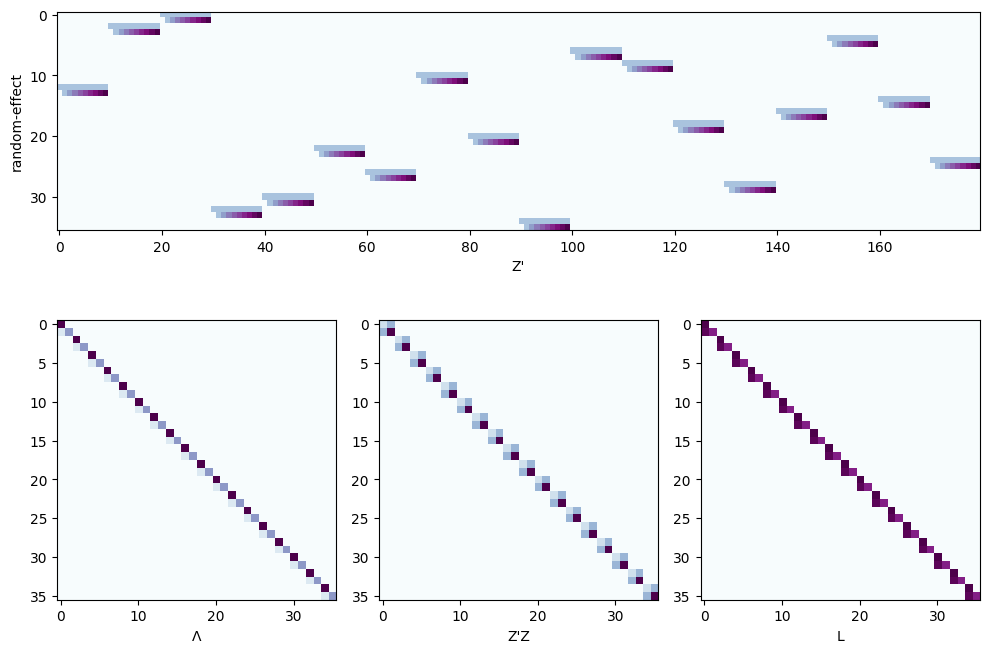

In [6]:
_ = fm06.plot_design()

In [7]:
fm07 = lme("Reaction ~ 1 + Days + (1|Subject) + (0+Days|Subject)", sleepstudy, REML=False)
fm07.summary()

Linear mixed model fit by maximum likelihood
Formula: Reaction ~ 1 + Days + (1|Subject) + (0+Days|Subject)

      AIC       BIC    logLik -2*log(L) df.resid
1762.0033 1777.9680 -876.0016 1752.0033      175

Scaled residuals:
    Min      1Q Median     3Q    Max
-3.9535 -0.4673 0.0239 0.4625 5.1883

Random effects:
 Groups    Name        Variance Std.Dev.
 Subject   (Intercept) 584.24   24.171
 Subject.1 Days        33.63    5.799
 Residual              653.12   25.556
Number of obs: 180, groups:  Subject, 18

Fixed effects:
             Estimate  Std. Error  t value
(Intercept)   251.405       6.708   37.480
Days           10.467       1.519    6.889

Correlation of Fixed Effects:
     (Intr)
Days -0.194


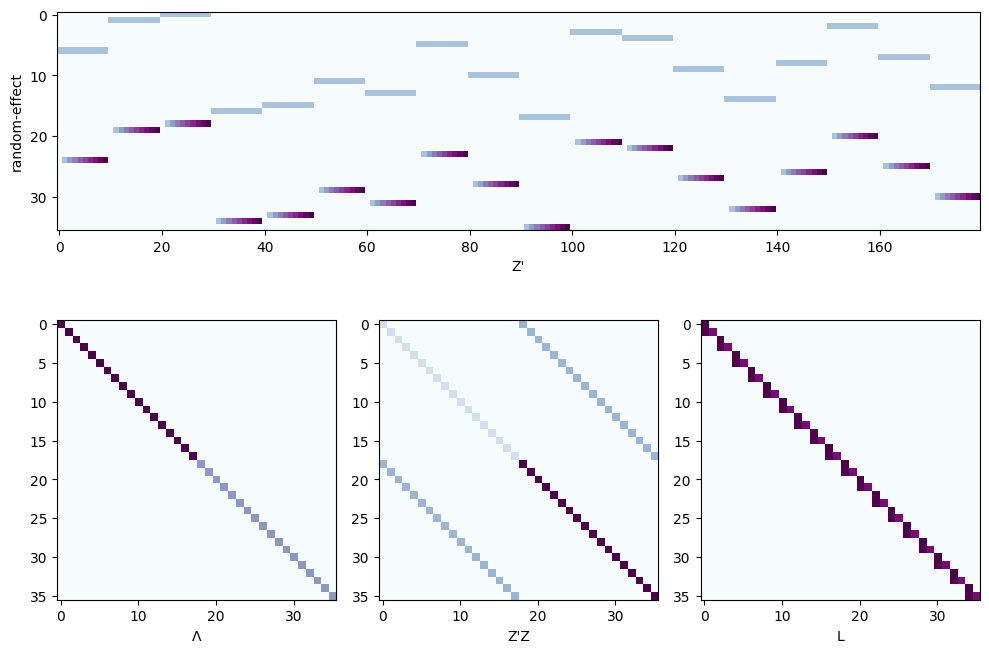

In [8]:
_ = fm07.plot_design()

In [9]:
anova(fm07, fm06)

Analysis of Variance Table (likelihood ratio test)

fm07: Reaction ~ 1 + Days + (1|Subject) + (0+Days|Subject)
fm06: Reaction ~ 1 + Days + (1 + Days|Subject)

      npar        AIC        BIC     logLik  -2*log(L)   Chisq  Df  Pr(>Chisq)
fm07     5  1762.0033  1777.9680  -876.0016  1752.0033
fm06     6  1763.9393  1783.0971  -875.9697  1751.9393  0.0639   1      0.8004
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [10]:
pr07 = fm07.profile()
pr07.confint()

parameter,2.5%,97.5%
str,f64,f64
""".sig01""",15.258668,37.786465
""".sig02""",3.964081,8.769149
""".sigma""",22.880555,28.787598
"""(Intercept)""",237.572125,265.238086
"""Days""",7.334062,13.600511


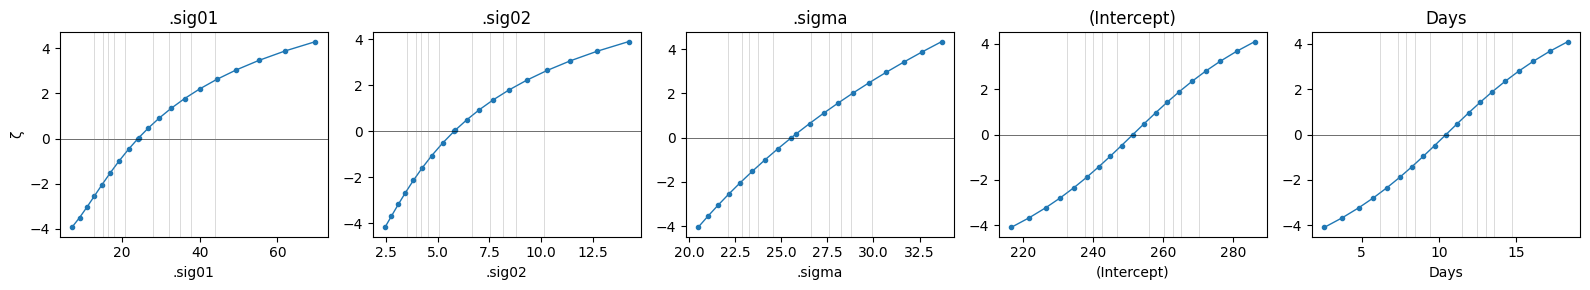

In [11]:
_ = pr07.plot()

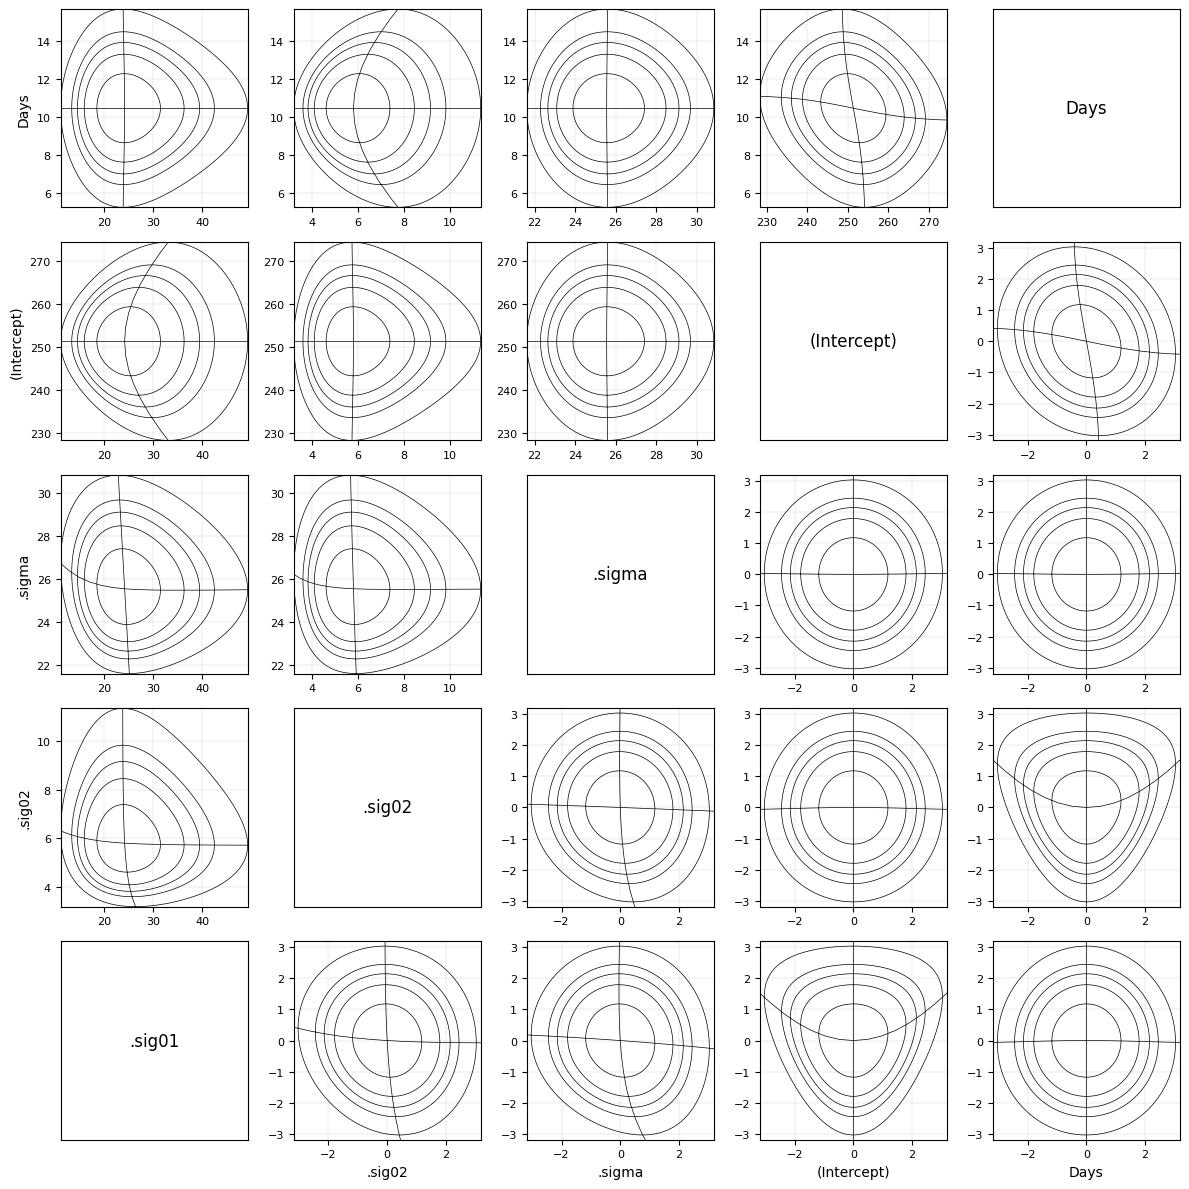

In [12]:
_ = pr07.plot_pairs()